## Занятие 10
## Математический анализ
## Кусочные функции, замена переменной в интеграле

In [66]:
import sympy
from sympy import S, Symbol, symbols, solve, solveset, integrate, Integral, diff, plot, Piecewise, latex
from sympy import sin as Sin
from sympy import cos as Cos
from sympy import exp as Exp
from sympy import log as Log
from sympy import pi as Pi
%matplotlib inline

### Задача 1
Описать функцию $F(x,a)=\int_a^x f(t)\,dt$, аргументами которой служат параметр $a$, функция $f$ и верхний предел $x$.

Построить на одном графике $F(x, a)$ для функции $f(t) = t^2\sin{t}$ при $a = 1/2, 1, 2$, $x \in [-\pi, \pi]$.

Найти производную построенной $F(x, a)$ по $x$ и сравнить с функцией $f$.

In [67]:
from sympy.abc import x, t

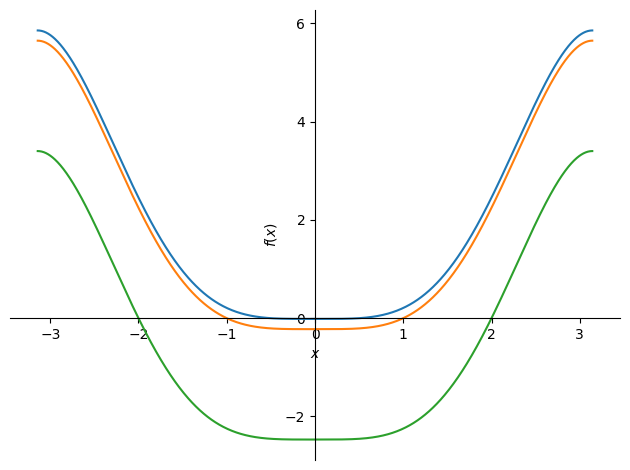

In [68]:
F1 = integrate(t ** 2 * Sin(t), (t, 1/2, x))
F2 = integrate(t ** 2 * Sin(t), (t, 1, x))
F3 = integrate(t ** 2 * Sin(t), (t, 2, x))
plot(F1, F2, F3, (x, -Pi, Pi))

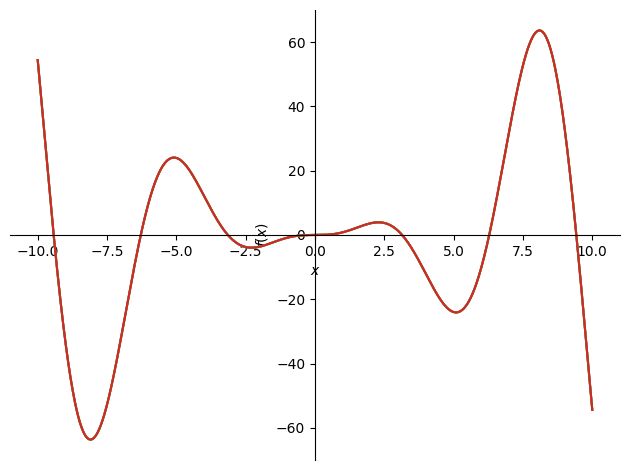

In [69]:
F1_integrate = diff(F1, x)
F2_integrate = diff(F2, x)
F3_integrate = diff(F3, x)
plot(F1_integrate, F2_integrate, F3_integrate, x ** 2 * Sin(x))

ВЫВОД: Производные совпадают с f

### Задача 2.
$$
sign(x)=\left\{\begin{matrix}
-1,\quad x<0\\
0,\quad x=0\\
1,\quad x>0
\end{matrix}\right.
$$
Описать кусочную функцию $sign(x)$ и функцию $F(x)=\int_{-1}^x sign(t)\,dt$, аргумент обеих функций $x$. Построить график $sign(x)$ красной сплошной линией и $F(x)$ зеленой в одной плоскости на интервале $[-1, 2]$.

In [70]:
from sympy import symbols, Piecewise, integrate
import matplotlib.pyplot as plt
import numpy as np

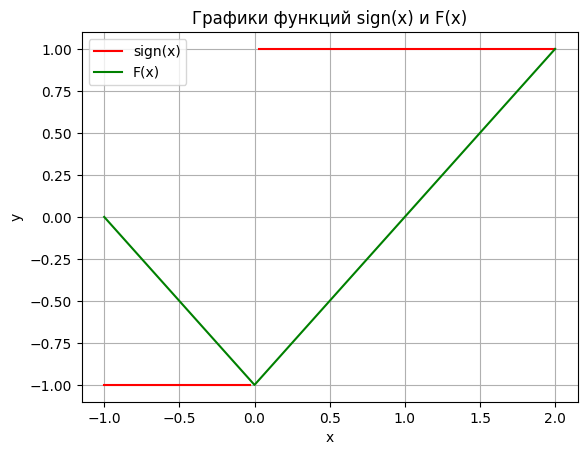

In [71]:
x = Symbol('x')
sign = Piecewise((-1, x <  0), (0, x ==  0), (1, x >  0))
x = symbols('x')
function_7 = sign.integrate((x, -1, x))
x_values = np.linspace(-1,  2,  100)
plt.plot(x_values, [sign.subs(x, val) for val in x_values], color='red', label='sign(x)')
values = [function_7.subs(x, val) for val in x_values]
plt.plot(x_values, values, color='green', label='F(x)')
plt.title("Графики функций sign(x) и F(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

### Задача 3.
Построить график зависимости  от $x$ площади под графиком функции $\sin t$ на отрезке $[0,x]$ при $x$ из $[\pi/2, \pi]$.
Подписать вертикальную ось $S(x)$.

In [16]:
def S_func(x):
    return integrate(Sin(t), (t, 0, x))
S_func(x)

1 - cos(x)

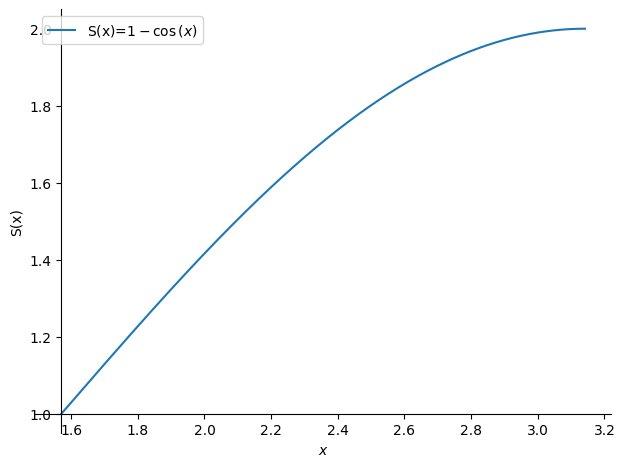

In [20]:
plot(S_func(x), (x, Pi / 2, Pi), axis_center=(Pi / 2, S_func(Pi / 2)), ylabel='S(x)', legend=True,
     label='S(x)=' + latex(S_func(x), mode='inline'))

### Задача 4.
В неопределенном интеграле $\int \frac1{2\sqrt x}e^{\sqrt x},\,dx$ провести замену переменной $x=u^2$, вычислить полученный интеграл, сделать обратную замену и проверить правильность полученного результата дифференцированием.
#### Указание.
Нужно использовать положительный символ $u$.

In [ ]:
x = symbols('x')
u = symbols('u', positive=True)
original_integral = Integral(1 / (2 * sympy.sqrt(x)) * sympy.exp(sympy.sqrt(x)))
substitution = u ** 2
integral_after_substitution = original_integral.transform(x, substitution)
integral_result = integrate(integral_after_substitution, u)
inverse_substitution = sympy.sqrt(x)
inverse_integral = integral_after_substitution.transform(u, inverse_substitution)
derivative_check = diff(inverse_integral, x)

In [ ]:
print("Исходный интеграл:")
display(original_integral)

Исходный интеграл:


Integral(exp(sqrt(x))/(2*sqrt(x)), x)

In [ ]:
print("Интеграл после замены переменной:")
display(integral_result)
display(integral_after_substitution)

Интеграл после замены переменной:


exp(u)

Integral(exp(u), u)

In [ ]:
print("Обратная замена переменной:")
display(inverse_integral)

Обратная замена переменной:


Integral(exp(sqrt(x))/(2*sqrt(x)), x)

In [ ]:
print("Проверка дифференцированием:")
display( derivative_check)

Проверка дифференцированием:


exp(sqrt(x))/(2*sqrt(x))

### Задача 5.
В определенном интеграле $$\int_1^2 (x-1)^3e^{(x-1)^4}\,dx$$ провести замену переменной $u = (x-1)^4$ и вычислить полученный интеграл.

In [11]:
x, y = symbols('x y', positive=True)
I = Integral((x - 1) ** 3 * Exp((x - 1) ** 4), (x, 1, 2))
I

Integral((x - 1)**3*exp((x - 1)**4), (x, 1, 2))

In [12]:
x, u = symbols('x u', positive=True)
I1 = I.transform((x - 1) ** 4, u)
I1

Integral(exp(u)/4, (u, 0, 1))

### Индивидуальное задание. Вариант №191

Вычислить площадь фигуры, ограниченной графиками функций f и g на интервале [a, b].
Построить графики, найти точки пересечения (выделить корни на интервале с помощью intersect и Interval), затем вычислить соответствующие интегралы.

f(x) = cos(x)

g(x) = cos (3x)

на интервале [0.5π; 1.0π].

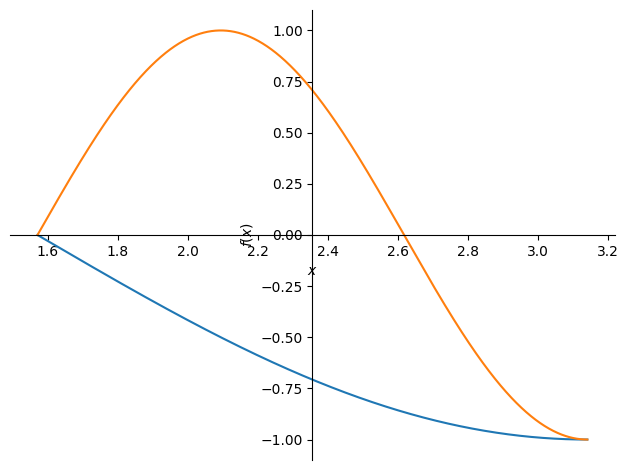

In [44]:
f = Cos(x)
g = Cos(3 * x)
plot(f, g, (x, S(1) / 2 * Pi, 1 * Pi))

In [57]:
import sympy

In [62]:
roots = solveset(sympy.Eq(f, g), x, domain = sympy.Interval(S(1) / 2 * Pi, Pi))
roots

{pi/2, pi}

In [63]:
S_fg = (f - g).integrate((x, min(roots), max(roots)))
abs(S_fg)

4/3